# Ablation Study Analysis

This notebook analyses the results produced by `scripts/run_ablations.py`.
Each experiment systematically removes one algorithmic component to quantify
its individual contribution to the final Pareto-front quality.

---

## Experiments

| ID | Config file | Component removed | Expected effect |
|----|-------------|-------------------|-----------------|
| T1 | `full_proposed.json` | — (full system) | Best HV / lowest IGD |
| T2 | `ablation_t2_no_pso.json` | PSO local refinement | Loss of topology-safe local search |
| T3 | `ablation_t3_no_ga.json` | GA global mutation | Loss of global exploration diversity |
| T4 | `ablation_t4_no_moead.json` | MOEA/D decomposition ($K=1$) | Collapse to single-direction search |
| T5 | `ablation_t5_no_sa.json` | Simulated Annealing | Greedy-only acceptance, local optima |
| T6 | `ablation_t6_no_restart.json` | Diversity restart | Premature convergence |

---

## Metrics

- **Hypervolume (HV)** — higher is better.  
  $$\text{HV}(A, r) = \lambda\!\left(\bigcup_{a \in A} [f_1(a),\, r_1] \times [f_2(a),\, r_2]\right)$$
- **IGD** — lower is better.  
  $$\text{IGD}(A, P^{\ast}) = \frac{1}{|P^{\ast}|}\sum_{p \in P^{\ast}} \min_{a \in A} \lVert p - a \rVert_2$$
- **Pareto size** — number of non-dominated solutions in the aggregate front.

Results files: `results/ablations/{experiment_name}_seed{N}.json`

In [3]:
# ── Setup ─────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.pareto_metrics import (
    archive_to_points, get_pareto_front, calc_hv, calc_igd, proxy_pareto,
)

ABLATION_DIR = PROJECT_ROOT / "results" / "ablations"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

EXPERIMENT_ORDER = [
    ("full_proposed", "T1 — Full Proposed"),
    ("no_pso",        "T2 — No PSO"),
    ("no_ga",         "T3 — No GA"),
    ("no_moead",      "T4 — No MOEA/D"),
    ("no_sa",         "T5 — No SA"),
    ("no_restart",    "T6 — No Restart"),
]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]


def load_ablation_archives(exp_name: str) -> list:
    archives = []
    for p in sorted(ABLATION_DIR.glob(f"{exp_name}_seed*.json")):
        payload = json.loads(p.read_text())
        archives.append(payload["archive"])
    return archives


print("Results directory:", ABLATION_DIR)
print("Run `python scripts/run_ablations.py` first if no results appear below.\n")

available = {name: load_ablation_archives(name) for name, _ in EXPERIMENT_ORDER}
for name, label in EXPERIMENT_ORDER:
    print(f"  {label:30s}  {len(available[name])} seed(s) found")

Results directory: /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablations
Run `python scripts/run_ablations.py` first if no results appear below.

  T1 — Full Proposed              5 seed(s) found
  T2 — No PSO                     5 seed(s) found
  T3 — No GA                      5 seed(s) found
  T4 — No MOEA/D                  5 seed(s) found
  T5 — No SA                      5 seed(s) found
  T6 — No Restart                 5 seed(s) found


In [7]:
# ── Build proxy P* and normalise ─────────────────────────────────────────
all_archives_flat = [a for arcs in available.values() for a in arcs]
if not all_archives_flat:
    raise RuntimeError("No ablation results found. Run scripts/run_ablations.py first.")

# ── Build proxy P* and normalise ─────────────────────────────────────────
all_archives_flat = [a for arcs in available.values() for a in arcs]
if not all_archives_flat:
    raise RuntimeError("No ablation results found. Run scripts/run_ablations.py first.")

rng = np.random.default_rng(42)
MAX_RUN_POINTS = 5000
MAX_PROXY_POINTS = 20000

p_star = np.empty((0, 2), dtype=np.float32)
for archive in all_archives_flat:
    pts = archive_to_points(archive)
    if pts.size == 0:
        continue

    if len(pts) > MAX_RUN_POINTS:
        pts = pts[rng.choice(len(pts), MAX_RUN_POINTS, replace=False)]

    pts = get_pareto_front(pts)
    if p_star.size == 0:
        p_star = pts.astype(np.float32, copy=False)
    else:
        p_star = get_pareto_front(np.vstack([p_star, pts]))

    if len(p_star) > MAX_PROXY_POINTS:
        selected = np.sort(rng.choice(len(p_star), MAX_PROXY_POINTS, replace=False))
        p_star = p_star[selected]

if p_star.size == 0:
    raise RuntimeError("No non-dominated points could be assembled for proxy P*.")

pts_min, pts_max = p_star.min(axis=0), p_star.max(axis=0)
range_ = np.where(pts_max - pts_min > 0, pts_max - pts_min, 1.0)

def normalise(pts: np.ndarray) -> np.ndarray:
    return (pts - pts_min) / range_

REF = np.array([1.1, 1.1])
print(f"Proxy P* size: {len(p_star)} non-dominated solutions across all ablation runs.")
rng = np.random.default_rng(42)
MAX_RUN_POINTS = 5000
MAX_PROXY_POINTS = 20000

p_star = np.empty((0, 2), dtype=np.float32)

for run in all_archives_flat:
    pts = archive_to_points(run).astype(np.float32, copy=False)
    if pts.size == 0:
        continue

    # Cap per-run points before Pareto extraction
    if len(pts) > MAX_RUN_POINTS:
        pts = pts[rng.choice(len(pts), MAX_RUN_POINTS, replace=False)]

    run_front = get_pareto_front(pts)

    if p_star.size == 0:
        merged = run_front
    else:
        merged = np.vstack([p_star, run_front])

    # Cap merged pool to avoid O(N^2) memory blowups inside Pareto filtering
    if len(merged) > MAX_PROXY_POINTS:
        merged = merged[rng.choice(len(merged), MAX_PROXY_POINTS, replace=False)]

    p_star = get_pareto_front(merged)

if p_star.size == 0:
    raise RuntimeError("Failed to build proxy P*: no valid points found.")
pts_min, pts_max = p_star.min(axis=0), p_star.max(axis=0)
range_ = np.where(pts_max - pts_min > 0, pts_max - pts_min, 1.0)

def normalise(pts: np.ndarray) -> np.ndarray:
    return (pts - pts_min) / range_

REF = np.array([1.1, 1.1])
print(f"Proxy P* size: {len(p_star)} non-dominated solutions across all ablation runs.")

Proxy P* size: 11346 non-dominated solutions across all ablation runs.
Proxy P* size: 11346 non-dominated solutions across all ablation runs.


In [8]:
# ── HV / IGD comparison table ─────────────────────────────────────────────
rows = []
for (name, label), color in zip(EXPERIMENT_ORDER, COLORS):
    arcs = available[name]
    if not arcs:
        continue
    hvs, igds = [], []
    for run in arcs:
        pts   = archive_to_points(run)
        front = get_pareto_front(pts)
        nf    = normalise(front)
        hvs.append(calc_hv(nf, ref_point=REF))
        igds.append(calc_igd(nf, normalise(p_star)))
    rows.append({
        "Experiment":        label,
        "Seeds":             len(arcs),
        "HV (mean ± std)":  f"{np.mean(hvs):.4f} ± {np.std(hvs):.4f}",
        "IGD (mean ± std)": f"{np.mean(igds):.4f} ± {np.std(igds):.4f}",
        "_hv":               np.mean(hvs),
        "_igd":              np.mean(igds),
    })

df = pd.DataFrame(rows).set_index("Experiment")
df["HV rank"]      = df["_hv"].rank(ascending=False).astype(int)
df["IGD rank"]     = df["_igd"].rank(ascending=True).astype(int)
df["Overall rank"] = (df["HV rank"] + df["IGD rank"]).rank(ascending=True).astype(int)
print(df.drop(columns=["_hv", "_igd"]).to_string())


Compiled modules for significant speedup can not be used!
https://pymoo.org/installation.html#installation

To disable this warning:
from pymoo.config import Config
Config.warnings['not_compiled'] = False

                    Seeds  HV (mean ± std) IGD (mean ± std)  HV rank  IGD rank  Overall rank
Experiment                                                                                  
T1 — Full Proposed      5  1.0465 ± 0.0008  0.0055 ± 0.0026        3         2             3
T2 — No PSO             5  1.0475 ± 0.0006  0.0060 ± 0.0022        1         3             2
T3 — No GA              5  0.8503 ± 0.0737  0.1021 ± 0.0264        6         6             6
T4 — No MOEA/D          5  1.0417 ± 0.0031  0.0294 ± 0.0250        5         5             5
T5 — No SA              5  1.0467 ± 0.0011  0.0055 ± 0.0025        2         1             1
T6 — No Restart         5  1.0465 ± 0.0008  0.0061 ± 0.0021        4         4             4


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablation_boxplots.pdf


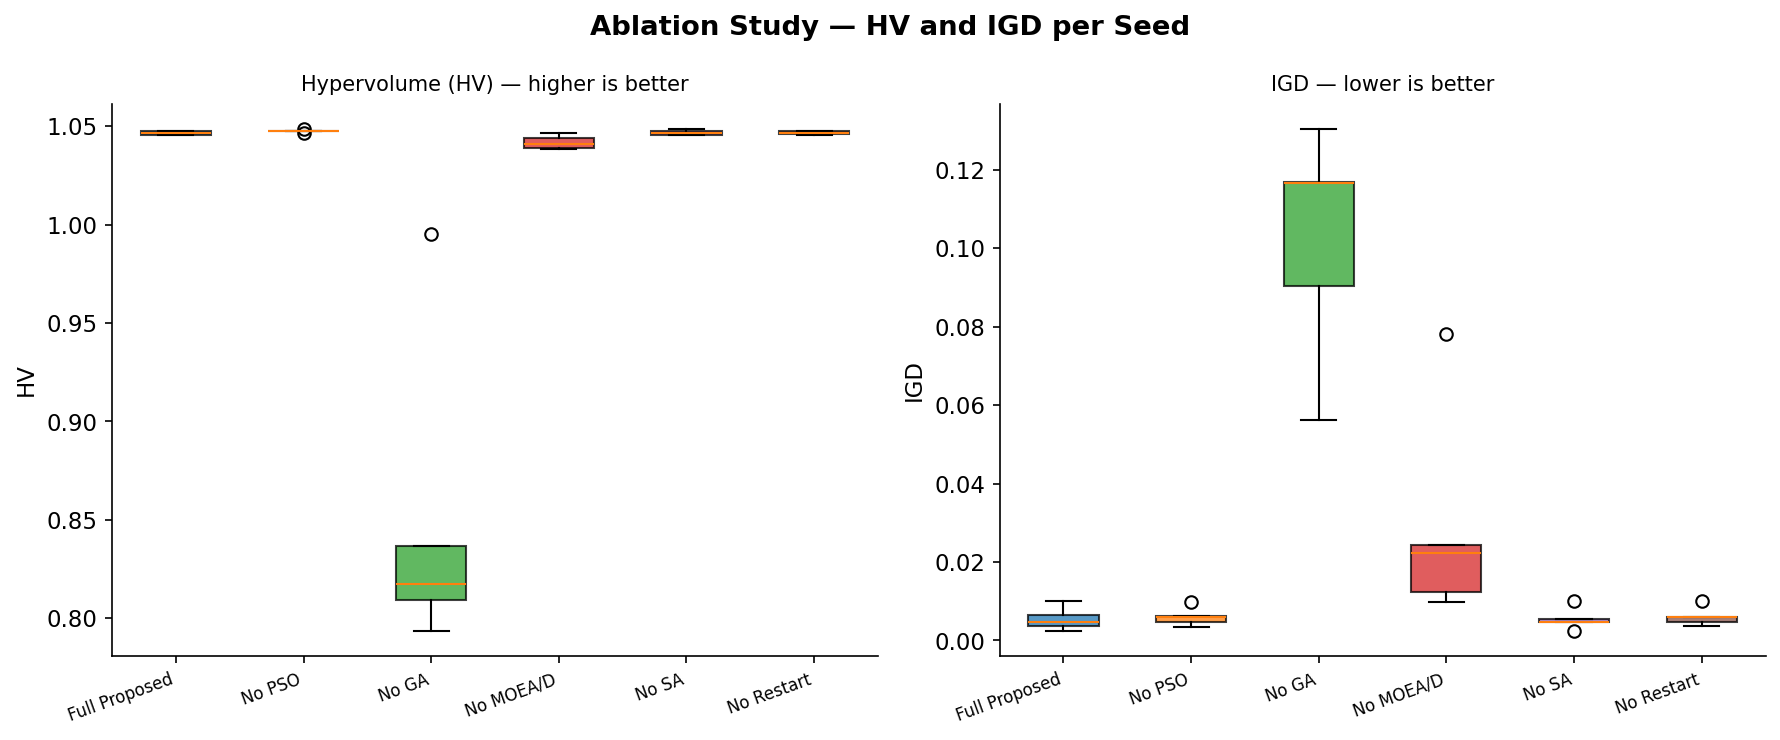

In [9]:
# ── HV boxplots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Ablation Study — HV and IGD per Seed", fontweight="bold")

hv_data, igd_data, labels_plot, colors_plot = [], [], [], []
for (name, label), color in zip(EXPERIMENT_ORDER, COLORS):
    arcs = available[name]
    if not arcs:
        continue
    hvs_run, igds_run = [], []
    for run in arcs:
        pts   = archive_to_points(run)
        front = get_pareto_front(pts)
        nf    = normalise(front)
        hvs_run.append(calc_hv(nf, ref_point=REF))
        igds_run.append(calc_igd(nf, normalise(p_star)))
    hv_data.append(hvs_run)
    igd_data.append(igds_run)
    labels_plot.append(label.split(" — ")[1])   # short label
    colors_plot.append(color)

bp_hv  = axes[0].boxplot(hv_data,  patch_artist=True, widths=0.55)
bp_igd = axes[1].boxplot(igd_data, patch_artist=True, widths=0.55)

for patch, color in zip(bp_hv["boxes"],  colors_plot):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for patch, color in zip(bp_igd["boxes"], colors_plot):
    patch.set_facecolor(color); patch.set_alpha(0.75)

for ax, title, ylabel in [
    (axes[0], "Hypervolume (HV) — higher is better", "HV"),
    (axes[1], "IGD — lower is better",               "IGD"),
]:
    ax.set_xticks(range(1, len(labels_plot) + 1))
    ax.set_xticklabels(labels_plot, rotation=20, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)

fig.tight_layout()
out = PROJECT_ROOT / "results" / "ablation_boxplots.pdf"
fig.savefig(out, bbox_inches="tight")
print(f"Saved → {out}")
plt.show()

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/ablation_pareto_overlay.pdf


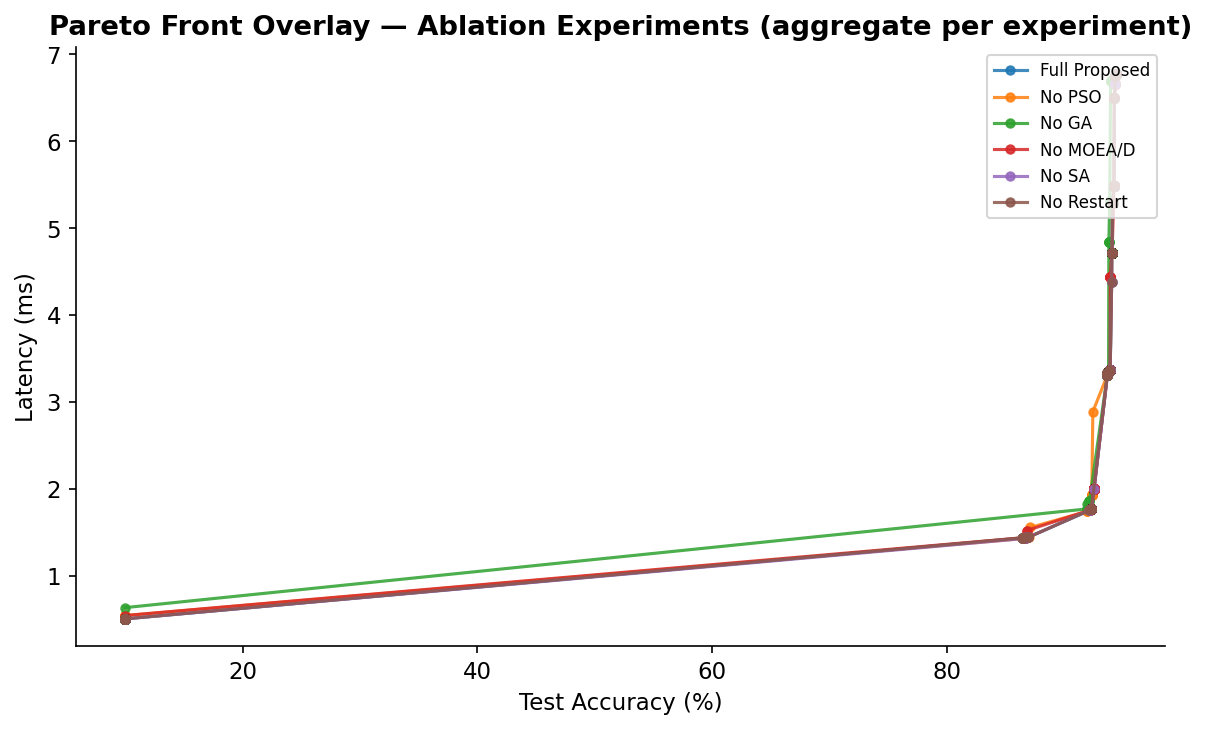

In [10]:
# ── Pareto front overlay ───────────────────────────────────────────────────
fig2, ax = plt.subplots(figsize=(8, 5))
ax.set_title(
    "Pareto Front Overlay — Ablation Experiments (aggregate per experiment)",
    fontweight="bold",
)

for (name, label), color in zip(EXPERIMENT_ORDER, COLORS):
    arcs = available[name]
    if not arcs:
        continue
    all_pts = np.vstack([archive_to_points(a) for a in arcs])
    front   = get_pareto_front(all_pts)
    # Convert to display space: (-acc, lat) → (acc, lat)
    acc_display = -front[:, 0]
    lat_display =  front[:, 1]
    order = np.argsort(acc_display)
    ax.plot(
        acc_display[order], lat_display[order],
        marker="o", markersize=4, linewidth=1.5,
        color=color, label=label.split(" — ")[1], alpha=0.85,
    )

ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.legend(fontsize=8, loc="upper right")
fig2.tight_layout()
out2 = PROJECT_ROOT / "results" / "ablation_pareto_overlay.pdf"
fig2.savefig(out2, bbox_inches="tight")
print(f"Saved → {out2}")
plt.show()